In [1]:
# ============================================================
# Step 8 — Cell 1: score all malignant cells on the 60 NNMF
# signatures (Filbin scorer, D5), then build the 60×60
# score-correlation matrix. NO clustering yet — inspect first.
# ============================================================
import numpy as np
import pandas as pd
import scanpy as sc

In [5]:
# ============================================================
# Step 8 — Cell 0: LOAD + Step 7 round-trip anchor verification
# Confirms the frozen state before any Step 8 work touches it.
# ============================================================
import numpy as np
import pandas as pd
import scanpy as sc

adata = sc.read_h5ad("../data/processed/Filbin_step7.h5ad")

TUMORS = ["MUV1", "MUV5", "MUV10", "BCH836", "BCH869", "BCH1126"]
K = 10

# --- Anchor 1: matrix shape (D9 cohort) ---
assert adata.shape == (2456, 8494), f"shape drift: {adata.shape}"

# --- Anchor 2: 60 signatures, 60×30, correctly named ---
sig_names = adata.uns["step7"]["signature_names"]
sig_matrix = adata.uns["step7"]["signatures"]
assert len(sig_names) == 60, f"expected 60 sig names, got {len(sig_names)}"
assert sig_matrix.shape == (60, 30), f"sig matrix shape {sig_matrix.shape}"
expected_names = [f"{t}_f{f}" for t in TUMORS for f in range(K)]
assert list(sig_names) == expected_names, "signature name/order drift"

# --- Anchor 3: per-tumor malignant N (NNMF input counts) ---
expected_N = {"MUV5": 704, "BCH869": 489, "BCH836": 441,
              "MUV10": 286, "BCH1126": 263, "MUV1": 146}
stored_N = adata.uns["step7"]["n_malignant_per_tumor"]
for t, n in expected_N.items():
    assert stored_N[t] == n, f"{t} malignant N: {stored_N[t]} != {n}"
assert sum(stored_N.values()) == 2329, f"total malignant {sum(stored_N.values())} != 2329"

# --- Anchor 4: X_nmf_H NaN-pad invariant ---
H = adata.obsm["X_nmf_H"]
assert H.shape == (2456, 10), f"H shape {H.shape}"
is_mal = adata.obs["is_malignant"].to_numpy(dtype=bool)
# malignant cells: fully finite; non-malignant: fully NaN
assert np.isfinite(H[is_mal]).all(), "malignant cell has NaN in X_nmf_H"
assert np.isnan(H[~is_mal]).all(), "non-malignant cell has non-NaN in X_nmf_H"
assert is_mal.sum() == 2329, f"is_malignant sum {is_mal.sum()} != 2329"

# --- Anchor 5: per-tumor W stack ---
W = adata.uns["step7_W"]
for t in TUMORS:
    assert W[t].shape == (8494, 10), f"{t} W shape {W[t].shape}"

# --- Anchor 6: concordance table present + cell-cycle universal ---
conc = pd.DataFrame(adata.uns["step7"]["concordance_vs_tableS5"])
assert len(conc) == 60, f"concordance rows {len(conc)}"
assert "step6_ambiguous" in adata.obs, "step6_ambiguous column missing"
assert adata.obs["step6_ambiguous"].sum() == 77, "step6_ambiguous count drift"

print("✓ All Step 7 round-trip anchors hold.")
print(f"  shape {adata.shape} | 60 sigs | malignant {is_mal.sum()} | ambiguous 77")
print(f"  per-tumor N: {dict(sorted(stored_N.items(), key=lambda x:-x[1]))}")

✓ All Step 7 round-trip anchors hold.
  shape (2456, 8494) | 60 sigs | malignant 2329 | ambiguous 77
  per-tumor N: {'MUV5': 704, 'BCH869': 489, 'BCH836': 441, 'MUV10': 286, 'BCH1126': 263, 'MUV1': 146}


In [7]:
TUMORS = ["MUV1", "MUV5", "MUV10", "BCH836", "BCH869", "BCH1126"]

sig_names = list(adata.uns["step7"]["signature_names"])          # 60, ordered
sig_matrix = adata.uns["step7"]["signatures"]                    # (60, 30) symbols
signatures = {sig_names[i]: list(sig_matrix[i]) for i in range(60)}

# --- substrate: Er (per-tumor centered) on malignant cells only ---
mal_mask = adata.obs["is_malignant"].to_numpy(dtype=bool)        # 2329 True
Er = adata.layers["centered_within_tumor"]                                    # (2456, 8494) = Eri,j
Er = np.asarray(Er.todense()) if not isinstance(Er, np.ndarray) else Er
Er_mal = Er[mal_mask, :]                                         # (2329, 8494)

# --- Ea for control binning, recomputed on THIS matrix (§B.5) ---
# Ea(i) = log2(mean(TPM_i over the scored cells) + 1). Filbin bins controls on Ea.
# Use malignant-cell TPM to match the population being scored.
tpm = adata.layers["tpm"]
tpm = np.asarray(tpm.todense()) if not isinstance(tpm, np.ndarray) else tpm
Ea = np.log2(tpm[mal_mask, :].mean(axis=0) + 1)                  # (8494,)
Ea = np.asarray(Ea).ravel()

genes = np.asarray(adata.var_names)
gene_pos = {g: i for i, g in enumerate(genes)}

# --- Filbin control-set scorer: 25 Ea-bins, 100 controls/gene, score on Er ---
N_BINS, N_CTRL_PER_GENE, SEED = 25, 100, 0
rng = np.random.default_rng(SEED)

# bin every gene by Ea (rank-based bins → ~equal occupancy, robust to Ea skew)
order = np.argsort(Ea, kind="mergesort")
bin_id = np.empty(len(Ea), dtype=int)
edges = np.linspace(0, len(Ea), N_BINS + 1).astype(int)
for b in range(N_BINS):
    bin_id[order[edges[b]:edges[b + 1]]] = b
bin_members = {b: np.where(bin_id == b)[0] for b in range(N_BINS)}

def score_signature(gene_list):
    idx = [gene_pos[g] for g in gene_list if g in gene_pos]
    if len(idx) == 0:
        return np.zeros(Er_mal.shape[0])
    # control set: for each signature gene, 100 genes from its Ea bin
    ctrl = []
    for gi in idx:
        pool = bin_members[bin_id[gi]]
        take = rng.choice(pool, size=min(N_CTRL_PER_GENE, len(pool)), replace=False)
        ctrl.append(take)
    ctrl = np.concatenate(ctrl)
    return Er_mal[:, idx].mean(axis=1) - Er_mal[:, ctrl].mean(axis=1)

# --- score all 60 signatures across the 2329 malignant cells ---
S = np.column_stack([score_signature(signatures[s]) for s in sig_names])  # (2329, 60)
scores = pd.DataFrame(S, columns=sig_names,
                      index=adata.obs_names[mal_mask])

# --- 60×60 Pearson correlation of the score vectors (Filbin's metric) ---
corr = np.corrcoef(S.T)                                          # (60, 60)
corr_df = pd.DataFrame(corr, index=sig_names, columns=sig_names)

# --- SANITY (inspect before clustering) ---
print("score matrix:", S.shape, "| finite:", np.isfinite(S).all())
print("per-signature score variance — degenerate (near-0) any?")
v = scores.var(axis=0)
print("  min var:", f"{v.min():.4g}", "| n with var<1e-6:", int((v < 1e-6).sum()))
print("\ncorr matrix:", corr.shape,
      "| symmetric:", np.allclose(corr, corr.T),
      "| diag≈1:", np.allclose(np.diag(corr), 1))
print("off-diagonal corr range:",
      f"[{corr[~np.eye(60,dtype=bool)].min():.3f}, {corr[~np.eye(60,dtype=bool)].max():.3f}]")

# quick peek: does each tumor's known cell-cycle factor correlate with the others'?
# (from Step 7: CC factors were MUV10 f3/f6, BCH869 f7/f8, BCH1126 f2/f4 — expect
#  high cross-tumor CC-CC correlation if the metric is capturing recurrence)
cc_probe = ["MUV10_f3", "BCH869_f7", "BCH1126_f2"]
cc_probe = [c for c in cc_probe if c in corr_df.index]
if len(cc_probe) >= 2:
    print("\ncross-tumor cell-cycle probe (should be clearly positive):")
    print(corr_df.loc[cc_probe, cc_probe].round(2).to_string())

score matrix: (2329, 60) | finite: True
per-signature score variance — degenerate (near-0) any?
  min var: 0.158 | n with var<1e-6: 0

corr matrix: (60, 60) | symmetric: True | diag≈1: True
off-diagonal corr range: [-0.613, 0.994]

cross-tumor cell-cycle probe (should be clearly positive):
            MUV10_f3  BCH869_f7  BCH1126_f2
MUV10_f3        1.00       0.71        0.66
BCH869_f7       0.71       1.00        0.97
BCH1126_f2      0.66       0.97        1.00


In [8]:
# ============================================================
# Step 8 — Cell 2: hierarchically cluster the 60 programs by
# 1 - Pearson corr of their score vectors, average linkage
# (Filbin convention). Does NOT hard-cut — surfaces block
# structure + per-cluster characterization for a joint cut call.
# ============================================================
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# --- distance: 1 - corr, condensed form for linkage ---
D = 1.0 - corr                          # (60,60), corr from Cell 1
np.fill_diagonal(D, 0.0)
D = 0.5 * (D + D.T)                      # enforce exact symmetry for squareform
condensed = squareform(D, checks=False)

Z = linkage(condensed, method="average")   # Filbin's correlation-clustering linkage

# --- leaf order (dendrogram) for reading block structure ---
dend = dendrogram(Z, labels=sig_names, no_plot=True)
leaf_order = dend["ivl"]
print("=== dendrogram leaf order (read blocks left→right) ===")
print(" ".join(leaf_order))

# --- concordance best-match per factor (from Step 7), for labeling ---
conc = pd.DataFrame(adata.uns["step7"]["concordance_vs_tableS5"]).set_index("factor")
best = conc["best_match"].to_dict()
bestov = conc["best_overlap"].to_dict()

# --- show cluster assignments at several candidate cut counts ---
def summarize(k):
    labs = fcluster(Z, t=k, criterion="maxclust")
    cl = pd.Series(labs, index=sig_names)
    print(f"\n{'='*60}\nCUT → {k} clusters\n{'='*60}")
    for c in sorted(cl.unique()):
        members = cl[cl == c].index.tolist()
        tumors = sorted({m.rsplit('_f',1)[0] for m in members})
        # dominant Table S5 match across members
        matches = [best.get(m,'—') for m in members]
        match_counts = pd.Series(matches).value_counts().to_dict()
        print(f"\n cluster {c}  (n={len(members)}, tumors={len(tumors)}/6)")
        print(f"   members : {members}")
        print(f"   TableS5 : {match_counts}")

for k in [3, 4, 5, 6, 7]:
    summarize(k)

# --- top recurrent genes per cluster at a chosen k (default 6 for inspection) ---
def cluster_top_genes(k, n_top=20):
    labs = fcluster(Z, t=k, criterion="maxclust")
    cl = pd.Series(labs, index=sig_names)
    print(f"\n{'#'*60}\nTOP RECURRENT GENES per cluster (k={k})\n{'#'*60}")
    for c in sorted(cl.unique()):
        members = cl[cl == c].index.tolist()
        # frequency of each gene across the cluster's member signatures
        from collections import Counter
        gc = Counter()
        for m in members:
            gc.update(signatures[m])
        top = [g for g,_ in gc.most_common(n_top)]
        tumors = sorted({m.rsplit('_f',1)[0] for m in members})
        print(f"\n cluster {c} (n={len(members)}, {len(tumors)} tumors): {top}")

cluster_top_genes(6, n_top=20)

=== dendrogram leaf order (read blocks left→right) ===
MUV5_f5 BCH1126_f6 MUV5_f4 BCH836_f7 BCH869_f6 MUV5_f0 BCH836_f3 BCH1126_f3 MUV10_f2 BCH836_f1 BCH869_f9 MUV10_f4 BCH1126_f4 MUV10_f3 BCH869_f8 BCH1126_f2 MUV10_f6 BCH869_f7 MUV1_f5 MUV5_f1 BCH836_f8 BCH869_f5 MUV1_f8 BCH869_f2 MUV1_f0 BCH836_f6 MUV5_f7 BCH869_f0 MUV10_f9 BCH1126_f9 MUV10_f7 BCH836_f2 BCH869_f4 MUV1_f1 MUV1_f7 BCH1126_f1 BCH1126_f7 MUV5_f8 MUV10_f0 BCH836_f9 MUV10_f8 BCH836_f5 BCH836_f4 BCH1126_f5 MUV5_f3 MUV5_f9 MUV1_f9 MUV1_f4 MUV1_f2 BCH869_f3 BCH1126_f0 BCH869_f1 MUV1_f6 MUV5_f2 MUV5_f6 BCH836_f0 MUV10_f1 MUV10_f5 MUV1_f3 BCH1126_f8

CUT → 3 clusters

 cluster 1  (n=21, tumors=6/6)
   members : ['MUV1_f5', 'MUV5_f0', 'MUV5_f1', 'MUV5_f4', 'MUV5_f5', 'MUV10_f2', 'MUV10_f3', 'MUV10_f4', 'MUV10_f6', 'BCH836_f1', 'BCH836_f3', 'BCH836_f7', 'BCH836_f8', 'BCH869_f6', 'BCH869_f7', 'BCH869_f8', 'BCH869_f9', 'BCH1126_f2', 'BCH1126_f3', 'BCH1126_f4', 'BCH1126_f6']
   TableS5 : {'Cellcycle': 11, 'OPC_shared': 6, 'OC': 3, '

=== merge-height gaps around candidate cuts ===
  k  cut_height  gap_to_next_merge
  2      1.0662 (collapses at 1.1098)
  3      1.0064 (collapses at 1.0225)
  4      0.9750 (collapses at 0.9903)
  5      0.9537 (collapses at 0.9597)
  6      0.9424 (collapses at 0.9478)
  7      0.9313 (collapses at 0.9369)
  8      0.9226 (collapses at 0.9257)

=== height jumps (large jump = natural cut point) ===
  1→2 clusters: Δheight=0.0873 #################
  2→3 clusters: Δheight=0.0322 ######
  3→4 clusters: Δheight=0.0306 ######
  4→5 clusters: Δheight=0.0119 ##
  5→6 clusters: Δheight=0.0109 ##
  6→7 clusters: Δheight=0.0112 ##
  7→8 clusters: Δheight=0.0062 #


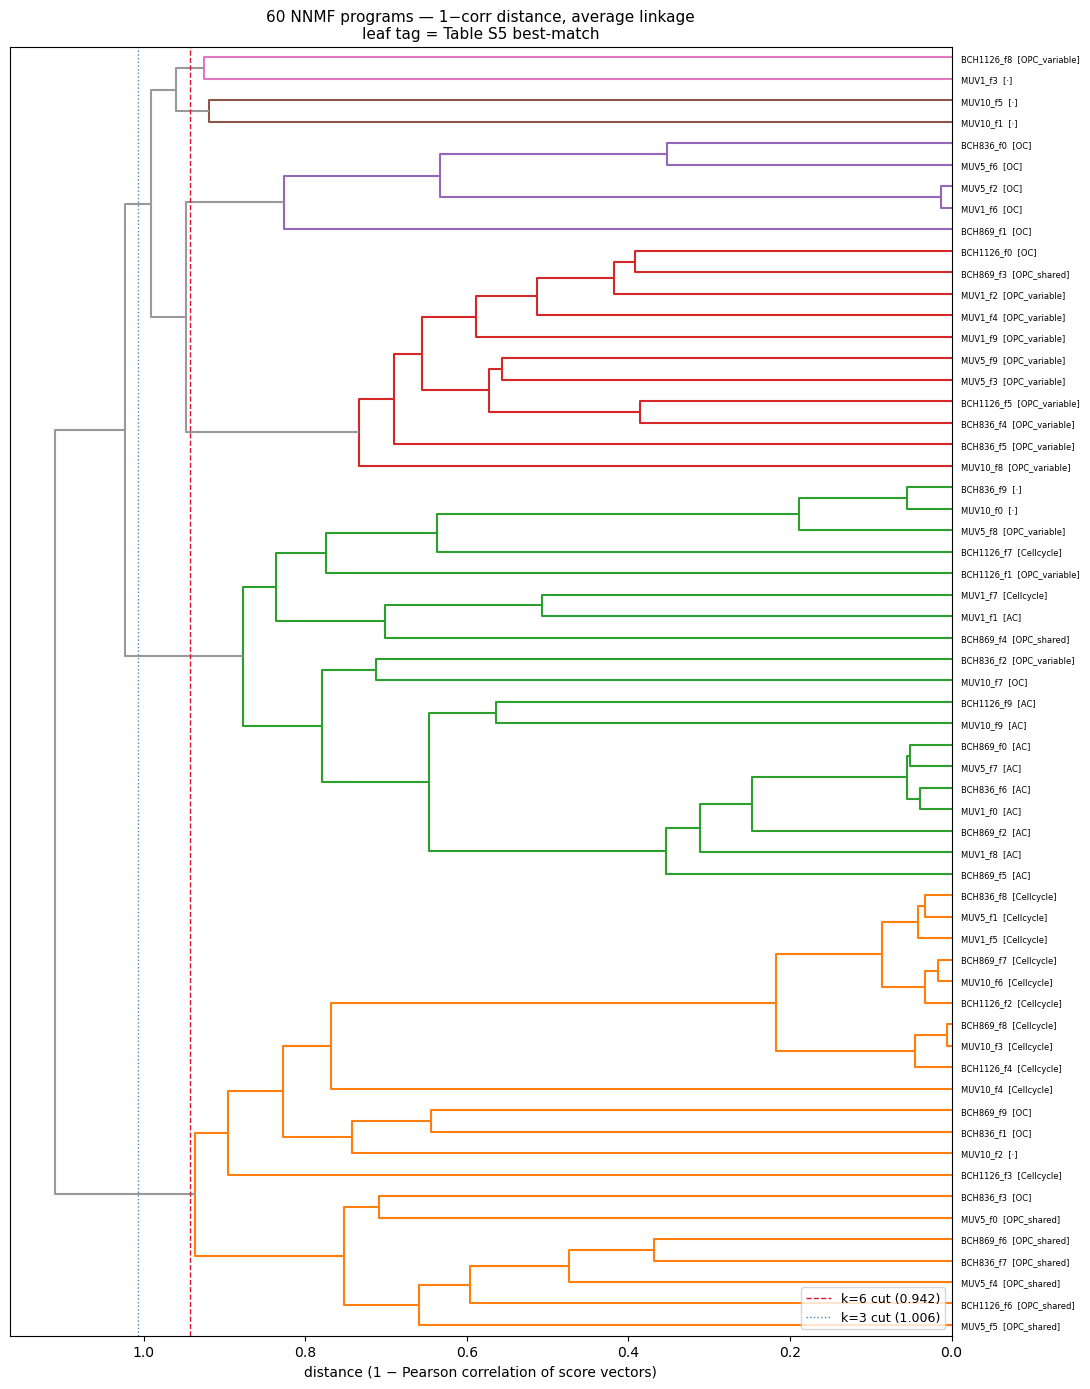


saved → ../figures/step8/step8_dendrogram_60programs.png


In [11]:
# ============================================================
# Step 8 — Cell 2b: visualize the 60-program dendrogram.
# Color threshold = k=6 cut. Leaf labels tagged with Table S5
# best-match. Prints merge heights to judge cut separation.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, fcluster

# --- map each candidate k to its cut height (for the threshold line) ---
# scipy: the cut for k clusters lies between merge heights [n-k-1] and [n-k]
heights = Z[:, 2]           # 59 merge heights, ascending
n = 60
def cut_height(k):
    # midpoint between the merge that would give k and k+1 clusters
    return 0.5 * (heights[n - k - 1] + heights[n - k])

print("=== merge-height gaps around candidate cuts ===")
print(f"{'k':>3} {'cut_height':>11} {'gap_to_next_merge':>18}")
for k in range(2, 9):
    ch = cut_height(k)
    # the height of the merge that collapses k→(k-1): heights[n-k]
    collapse = heights[n - k]
    print(f"{k:>3} {ch:>11.4f} {'(collapses at '+format(collapse,'.4f')+')':>18}")

# a big jump between successive collapse heights = a well-separated cut
print("\n=== height jumps (large jump = natural cut point) ===")
for k in range(2, 9):
    jump = heights[n - k] - heights[n - k - 1]
    bar = "#" * int(jump * 200)
    print(f"  {k-1}→{k} clusters: Δheight={jump:.4f} {bar}")

# --- leaf labels: factor + Table S5 tag ---
tag = {f: (best.get(f, '—') if best.get(f,'—') != '—' else '·') for f in sig_names}
labels = [f"{f}  [{tag[f]}]" for f in sig_names]

# --- draw ---
fig, ax = plt.subplots(figsize=(11, 14))
dcut = cut_height(6)
dendrogram(
    Z,
    labels=labels,
    orientation="left",
    color_threshold=dcut,
    above_threshold_color="#999999",
    ax=ax,
)
ax.axvline(dcut, color="crimson", ls="--", lw=1, label=f"k=6 cut ({dcut:.3f})")
ax.axvline(cut_height(3), color="steelblue", ls=":", lw=1, label=f"k=3 cut ({cut_height(3):.3f})")
ax.set_title("60 NNMF programs — 1−corr distance, average linkage\n"
             "leaf tag = Table S5 best-match", fontsize=11)
ax.set_xlabel("distance (1 − Pearson correlation of score vectors)")
ax.tick_params(axis="y", labelsize=6)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("../figures/step8/step8_dendrogram_60programs.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nsaved → ../figures/step8/step8_dendrogram_60programs.png")

In [12]:
# ============================================================
# Step 8 — Cell 3: k=3 partition → assign P1/P2/P3 by gene
# content against Fig.2A marker panels, isolate technical pairs,
# then re-derive each meta-program's top-30 by correlation-to-
# set-mean (Filbin's method). Closes the Step 5 approximation.
# ============================================================
import numpy as np
import pandas as pd
from collections import Counter
from scipy.cluster.hierarchy import fcluster

# --- Fig. 2A / main-text marker panels (ground truth for labeling) ---
FIG2A_MARKERS = {
    "P1_cellcycle": ["CDK1", "RRM2", "TOP2A", "PCNA", "MKI67", "TYMS", "BIRC5",
                     "HMGB2", "NUSAP1", "TPX2", "PTTG1", "UBE2T", "ZWINT"],
    "P2_AC":        ["VIM", "GFAP", "APOE", "ALDOC", "HEY1", "SPARC", "AQP4",
                     "CLU", "AGT", "MLC1", "GJA1", "SPARCL1"],
    "P3_OC":        ["PLP1", "MBP", "TF", "MOG", "CLDN11", "MAG", "MOBP",
                     "PTGDS", "ERMN", "KLK6", "CNP"],
    "P4_OPC":       ["PDGFRA", "CCND1", "CD24", "ASCL1", "ETV1", "HES6",
                     "EGR2", "CSPG4", "OLIG1", "OLIG2", "SOX8"],
}

# --- the technical outgroups (early-splitting, non-recurrent) ---
TECHNICAL = {"BCH1126_f8", "MUV1_f3", "MUV10_f1", "MUV10_f5"}

# --- k=3 partition ---
labs3 = fcluster(Z, t=3, criterion="maxclust")
cl3 = pd.Series(labs3, index=sig_names, name="k3")

def recurrent_genes(members, n=40):
    gc = Counter()
    for m in members:
        gc.update(signatures[m])
    return gc

def panel_hits(gene_counter, n_top=40):
    """How strongly do a cluster's top recurrent genes hit each Fig.2A panel?"""
    top = {g for g, _ in gene_counter.most_common(n_top)}
    return {p: len(top & set(mk)) for p, mk in FIG2A_MARKERS.items()}

print("=== k=3 clusters — Fig.2A panel hits on top-40 recurrent genes ===")
cluster_panel = {}
for c in sorted(cl3.unique()):
    members = [m for m in cl3[cl3 == c].index if m not in TECHNICAL]
    gc = recurrent_genes(members)
    hits = panel_hits(gc)
    cluster_panel[c] = hits
    tumors = sorted({m.rsplit('_f', 1)[0] for m in members})
    print(f"\n cluster {c} (n={len(members)} non-tech, {len(tumors)}/6 tumors)")
    print(f"   panel hits: {hits}")
    print(f"   top-15 recurrent: {[g for g,_ in gc.most_common(15)]}")

# --- WITHIN-cluster gene-content check: is cell-cycle smeared? ---
# For each factor, which panel does ITS OWN top-30 hit hardest?
def factor_panel(f):
    s = set(signatures[f])
    hits = {p: len(s & set(mk)) for p, mk in FIG2A_MARKERS.items()}
    best = max(hits, key=hits.get)
    return best if hits[best] > 0 else "—", hits

print("\n=== per-factor dominant panel (to catch cell-cycle smearing) ===")
factor_assign = {}
for f in sig_names:
    if f in TECHNICAL:
        factor_assign[f] = "TECHNICAL"
        continue
    best, hits = factor_panel(f)
    factor_assign[f] = best
    
# summary: how do per-factor assignments distribute across k=3 clusters?
asg = pd.DataFrame({"k3": cl3, "panel": pd.Series(factor_assign)})
print(pd.crosstab(asg["k3"], asg["panel"]).to_string())

=== k=3 clusters — Fig.2A panel hits on top-40 recurrent genes ===

 cluster 1 (n=21 non-tech, 6/6 tumors)
   panel hits: {'P1_cellcycle': 12, 'P2_AC': 0, 'P3_OC': 0, 'P4_OPC': 2}
   top-15 recurrent: ['HMGB2', 'MAD2L1', 'PBK', 'PCP4', 'NUSAP1', 'PTTG1', 'UBE2T', 'TOP2A', 'TPX2', 'CDK1', 'FAM64A', 'TYMS', 'MLF1IP', 'ZWINT', 'BIRC5']

 cluster 2 (n=19 non-tech, 6/6 tumors)
   panel hits: {'P1_cellcycle': 0, 'P2_AC': 10, 'P3_OC': 0, 'P4_OPC': 1}
   top-15 recurrent: ['VIM', 'SPARCL1', 'AQP4', 'EDNRB', 'PLTP', 'APOE', 'AGT', 'CLU', 'HOPX', 'MLC1', 'ALDOC', 'CRYAB', 'S100A16', 'JUN', 'GJA1']

 cluster 3 (n=16 non-tech, 6/6 tumors)
   panel hits: {'P1_cellcycle': 0, 'P2_AC': 0, 'P3_OC': 6, 'P4_OPC': 2}
   top-15 recurrent: ['GPR17', 'CA10', 'FABP7', 'LHFPL3', 'PDGFRA', 'LPPR1', 'PTGDS', 'HMP19', 'SIRT2', 'MPZL1', 'SCRG1', 'PLLP', 'CHGB', 'LNX1', 'PLP1']

=== per-factor dominant panel (to catch cell-cycle smearing) ===
panel  P1_cellcycle  P2_AC  P3_OC  P4_OPC  TECHNICAL  —
k3               